# Portfolio VaR and Stress Testing Model

## 1. Introduction and Objectives

Value-at-Risk (VaR) is a standard benchmark in quantitative risk management and is used to quantify the maximum expected loss of an investment or portfolio over a defined holding period at a given statistical confidence level. However, standard methods of calculating VaR rely on different assumptions about how returns behave, particularly in extreme, tail-risk scenarios, and these assumptions can break down when they matter most.

**Modelling assumptions:** For this project VaR is calculated for a portfolio of value $100,000 with a 1-day holding period, unless stated otherwise.

This project builds and compares three VaR approaches:

-**Historical Simulation**: Uses actual past returns, with no distributional assumptions

-**Parametric (Variance-Covariance)**: Assumes that all returns are normally distributed

-**Monte Carlo Simulation**: Simulates thousands of randomised future price paths using Geometric Brownian Motion, accounting for correlations between assets

### Objectives:

1. **Cross Portfolio Comparison** - apply all three models to three portfolios with three distinct risk profiles (namely Sector-Diversified, High-Beta & Financials Heavy, and Defensive/Inflation Hedge), and check whether the models correctly rank them by risk

2. **Model Assumptions vs Reality** - examine where each method of caluculation's assumptions (eg. normal returns) cause it to under or overestimate risk compared to what really happens in the data

3. **Stress Testing & Validation** - test each model against a historical crisis period to see how well it holds up, and backtest to check how often real loses exceeded the predicted VaR



## 2. Portfolio Selection

In order to test how each method of calculating VaR performs across different risk profiles, this project uses three portfolios, each built from the following pool of 12 large-cap, liquid US equities across 6 sectors.

| Sector               | Ticker   | Company Name      | Reason for Choice                                                              |
| -------------------- | -------- | ----------------- | ------------------------------------------------------------------------------ |
| **Technology**       | **NVDA** | NVIDIA            | High-beta with historically high volatility                                    |
|                      | **MSFT** | Microsoft         | Mega-cap stock with relatively stable returns                                  |
|                      | **AAPL** | Apple             | Highly liquid mega-cap with broad market exposure                              |
| **Financials**       | **JPM**  | JPMorgan Chase    | Large diversified bank with exposure to both commercial and investment banking |
|                      | **BX**   | Blackstone Inc.   | Alternative asset manager with a different risk profile to other banks         |
| **Healthcare**       | **JNJ**  | Johnson & Johnson | Low-beta defensive stock with relatively stable performance                    |
|                      | **PFE**  | Pfizer            | Established pharmaceutical company with relatively defensive cash flows        |
| **Consumer Staples** | **PG**   | Procter & Gamble  | Defensive consumer stock with lower sensitivity to economic growth             |
|                      | **KO**   | Coca-Cola         | Defensive business with stable cash flows and consistent dividends             |
| **Energy**           | **XOM**  | ExxonMobil        | Energy major providing exposure to commodity prices and macroeconomic risk     |
|                      | **CVX**  | Chevron           | Integrated energycompany with strong cash-flow exposure to the energy cycle    |
| **Industrials**      | **CAT**  | Caterpillar       | Cyclical industrial with strong exposure to global economic conditions         |


### Portfolio 1: Sector-Diversified

This is an equally-weighted portfolio spanning all six sectors, used as a baseline to test whether diversification meaningfully reduces VaR compared to the more concentrated portfolios below.

| Ticker | Company           | Sector           | Weight |
| ------ | ----------------- | ---------------- | ------ |
| NVDA   | NVIDIA            | Technology       | 8.33%  |
| MSFT   | Microsoft         | Technology       | 8.33%  |
| AAPL   | Apple             | Technology       | 8.33%  |
| JPM    | JPMorgan Chase    | Financials       | 8.33%  |
| BX     | Blackstone Inc.   | Financials       | 8.33%  |
| JNJ    | Johnson & Johnson | Healthcare       | 8.33%  |
| PFE    | Pfizer            | Healthcare       | 8.33%  |
| PG     | Procter & Gamble  | Consumer Staples | 8.33%  |
| KO     | Coca-Cola         | Consumer Staples | 8.33%  |
| XOM    | ExxonMobil        | Energy           | 8.33%  |
| CVX    | Chevron           | Energy           | 8.33%  |
| CAT    | Caterpillar       | Industrials      | 8.33%  |


### Portfolio 2: High-Beta & Financials Heavy

This is a concentrated, growth-tilted portfolio weighted towards volatile technology and financial companies which is expected to show a higher VaR than the diversified portfolio.

| Ticker | Company        | Sector      | Weight |
| ------ | -------------- | ----------- | ------ |
| NVDA   | NVIDIA         | Technology  | 25%    |
| MSFT   | Microsoft      | Technology  | 15%    |
| AAPL   | Apple          | Technology  | 15%    |
| JPM    | JPMorgan Chase | Financials  | 15%    |
| BX     | Blackstone     | Financials  | 20%    |
| CAT    | Caterpillar    | Industrials | 10%    |


### Portfolio 3: Defensive / Inflation Hedged

This portfolio is tilted towards historically defensive sectors like healthcare and consumer staples, and combines it with energy exposure as an inflation hedge. This creates a deliberate tension as healthcare/staples are low-volatility, but energy stocks are historically more volatile than the market average, driven by many macroeconomic factors. This portfolio is therefore not a "pure" low-risk portfolio and it's VaR is expected to sit between that of a defensive, and that of a higher volatility portfolio.

| Ticker | Company           | Sector           | Weight |
| ------ | ----------------- | ---------------- | ------ |
| JNJ    | Johnson & Johnson | Healthcare       | 20%    |
| PFE    | Pfizer            | Healthcare       | 15%    |
| PG     | Procter & Gamble  | Consumer Staples | 20%    |
| XOM    | ExxonMobil        | Energy           | 12.5%  |
| CVX    | Chevron           | Energy           | 12.5%  |


**Expected Outcome:** Portfolio 2 (concentrated, high-beta) is expected to show the highest VaR. Portfolio 1 (fully diversified) is expected to show a low VaR. Portfolio 3's result is less certain, it's healthcare/staples base suggests lower risk, but its energy weighting may push its VaR closer to that of Portfolio 1 or even above. This will test whether "defensive" framing actually translates to lower measured risk. This ambiguity is revisited once all three models are built.




## 3. Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

In [2]:
portfolio1 = { #Sector Diversified
    'NVDA':1/12,'MSFT':1/12,'AAPL':1/12,'JPM':1/12,
    'BX':1/12,'JNJ':1/12,'PFE':1/12,'PG':1/12,
    'KO':1/12, 'XOM':1/12,'CVX':1/12,'CAT':1/12}

portfolio2 = { #High-Beta Financials Heavy
    'NVDA':0.25, 'MSFT':0.15, 'AAPL':0.15, 'JPM':0.15,
    'BX':0.2, 'CAT':0.1}

portfolio3 = { #Defensive / Inflation Hedge
    'JNJ':0.2, 'PFE':0.15, 'PG':0.2, 'KO':0.2, 'XOM':0.125, 'CVX':0.125}

In [3]:
#Creating a list of unique tickers from all three portfolios and then pulling the adjusted closing prices for those tickers from 2016-2026
tickers = list(set(portfolio1.keys() | portfolio2.keys() | portfolio3.keys()))

close_prices = yf.download(tickers, start='2016-01-01', end='2026-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  11 of 12 completed


In [4]:
print(close_prices.isna().sum())  # Check for missing values

Ticker
AAPL    0
BX      0
CAT     0
CVX     0
JNJ     0
JPM     0
KO      0
MSFT    0
NVDA    0
PFE     0
PG      0
XOM     0
dtype: int64


This shows we have no missing values for closing prices and therefore we can commit this data

In [5]:
close_prices.to_csv("../data/close_prices.csv")

In [6]:
pct_return = close_prices.pct_change().dropna()  # Calculate daily percentage changes and drop NaN values

log_return = np.log(close_prices / close_prices.shift(1)).dropna()  # Calculate daily log returns and drop NaN values (will be important later on)

## 4. Exploratory Analysis

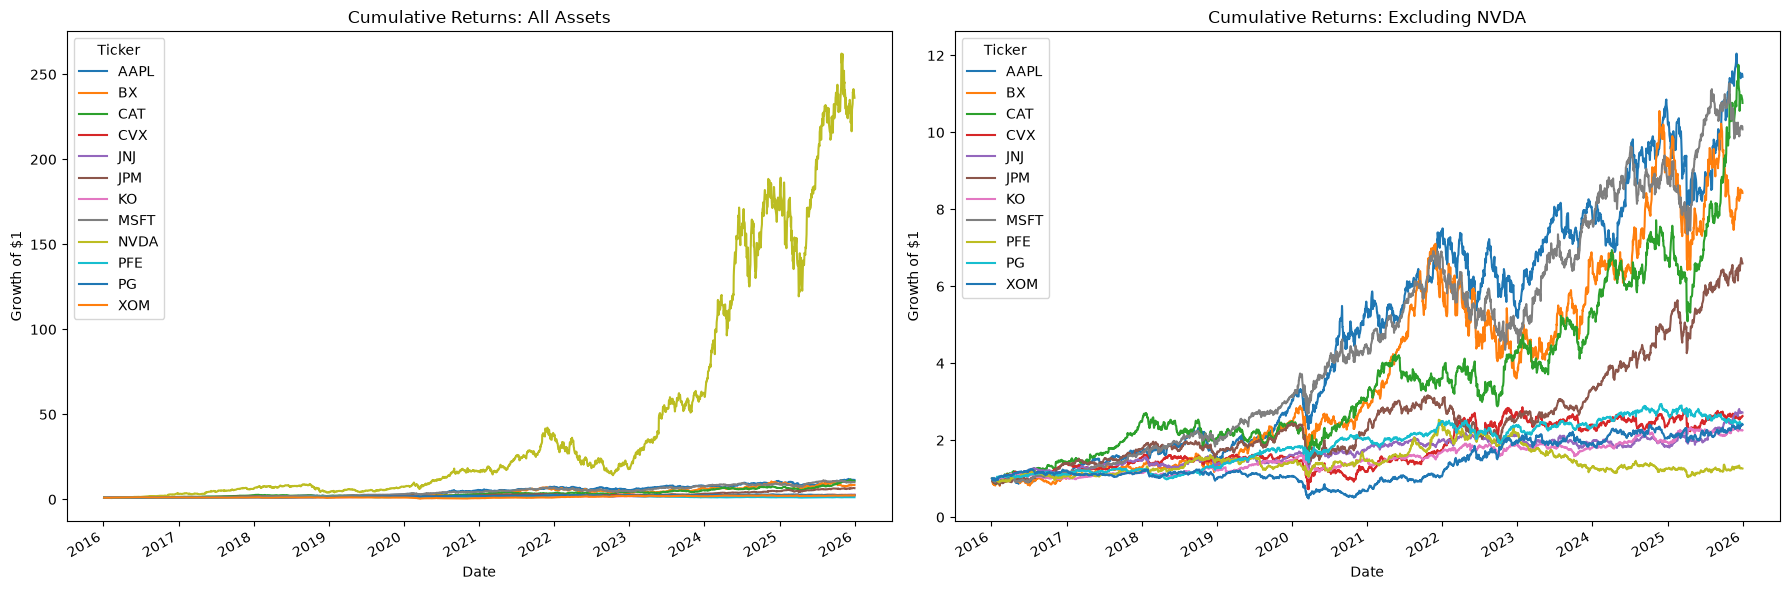

In [7]:
cumulative_return = (1 + pct_return).cumprod() # Calculate cumulative returns on $1

fig, axes=plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

cumulative_return.plot(
    ax=axes[0], 
    title='Cumulative Returns: All Assets', 
    ylabel='Growth of $1')

cumulative_return.drop(columns=['NVDA']).plot(
    ax=axes[1],
    title='Cumulative Returns: Excluding NVDA',
    ylabel='Growth of $1')

plt.tight_layout()
plt.show()


We can see here that NVIDIA's performance compresses linear scales, showing why it's important visual models and statistical analysis must account for extreme skewness and heavy tails

## 5. Historical Simulation VaR

Historical Simulation is a non-parametric approach to calculating VaR that relies directly on empirical market data rather than assuming returns follow some distribution. Conceptually, the model applies today's portfolio allocation ($100,000 base value) to every actual historical trading day from 2016-01-01 to 2026-01-01, reconstructing how the portfolio would've performed across approximately 2500 historical scenarios. By sorting these daily profit or loss outcomes from worst to best, the 1-day VaR is simply the loss threshold corresponding to the chosen statistical cutoff (eg. 5th percentile for a 95% confidence level).

In [8]:
#First we need to set up the weights for each portfolio. We will create a weight vector for each portfolio that has the same length as the number of assets in the pct_return dataframe (the 12 chosen). The weights will be set to 0 for any asset that is not in the portfolio.
weightspf1 = np.array([portfolio1.get(ticker, 0) for ticker in pct_return.columns])
weightspf2 = np.array([portfolio2.get(ticker, 0) for ticker in pct_return.columns])
weightspf3 = np.array([portfolio3.get(ticker, 0) for ticker in pct_return.columns])


#Now we have weight vector for each portfolio, we can calculate the portfolio returns by taking the dot product of the percentage returns and the weight vector for each portfolio. This will give us a single time series of returns for each portfolio.
portfolio1_returnspct= pct_return.dot(weightspf1)
portfolio2_returnspct = pct_return.dot(weightspf2)
portfolio3_returnspct = pct_return.dot(weightspf3)

#Turning these into dollar returns by multiplying by the initial investment of $100,000
portfolio1_returns = portfolio1_returnspct * 100000 
portfolio2_returns = portfolio2_returnspct * 100000
portfolio3_returns = portfolio3_returnspct * 100000

#We can look at the first few rows of the portfolio returns to see what they look like
print(portfolio1_returns.head())
print(portfolio2_returns.head())
print(portfolio3_returns.head())


Date
2016-01-05     -49.538395
2016-01-06   -1876.219894
2016-01-07   -2665.518838
2016-01-08   -1264.169045
2016-01-11    -575.924587
dtype: float64
Date
2016-01-05    -543.922657
2016-01-06   -2577.987024
2016-01-07   -3763.727639
2016-01-08   -1516.157998
2016-01-11    -700.677308
dtype: float64
Date
2016-01-05     539.570146
2016-01-06   -1266.041057
2016-01-07   -1481.259986
2016-01-08   -1157.689508
2016-01-11    -242.677196
dtype: float64


Now we have all the returns for holding each portfolio on each day in our time frame.

In [9]:
#We can now calculate the VaR simply by using the quantile function on the portfolio returns. We will start with a 95% confidence level, which corresponds to the 5th percentile of the returns distribution.
histvar95_pf1 = abs(portfolio1_returns.quantile(0.05))
histvar95_pf2 = abs(portfolio2_returns.quantile(0.05))
histvar95_pf3 = abs(portfolio3_returns.quantile(0.05))

print(f"Portfolio 1 Historical VaR (95% confidence): ${histvar95_pf1:.2f}")
print(f"Portfolio 2 Historical VaR (95% confidence): ${histvar95_pf2:.2f}")
print(f"Portfolio 3 Historical VaR (95% confidence): ${histvar95_pf3:.2f}")

Portfolio 1 Historical VaR (95% confidence): $1594.25
Portfolio 2 Historical VaR (95% confidence): $2575.84
Portfolio 3 Historical VaR (95% confidence): $1347.92


In [10]:
#We can easily now quickly calculate the 99% confidence level VaR by changing the quantile to 0.01
histvar99_pf1 = abs(portfolio1_returns.quantile(0.01))
histvar99_pf2 = abs(portfolio2_returns.quantile(0.01))
histvar99_pf3 = abs(portfolio3_returns.quantile(0.01))

print(f"Portfolio 1 Historical VaR (99% confidence): ${histvar99_pf1:.2f}")
print(f"Portfolio 2 Historical VaR (99% confidence): ${histvar99_pf2:.2f}")
print(f"Portfolio 3 Historical VaR (99% confidence): ${histvar99_pf3:.2f}")

Portfolio 1 Historical VaR (99% confidence): $3314.07
Portfolio 2 Historical VaR (99% confidence): $4774.18
Portfolio 3 Historical VaR (99% confidence): $2507.13


In [11]:
histvar_summary = pd.DataFrame(
    {
        "Portfolio": 
        ["Portfolio 1 (Sector Diversified)", 
         "Portfolio 2 (High-Beta Financials Heavy)", 
         "Portfolio 3 (Defensive/Inflation Hedged)"],

         "1-Day 95% VaR":
         [histvar95_pf1, histvar95_pf2, histvar95_pf3],

        "1-Day 99% VaR":
         [histvar99_pf1, histvar99_pf2, histvar99_pf3]
    }
).set_index("Portfolio")   

display(histvar_summary.style.format("${:,.2f}"))

,1-Day 95% VaR,1-Day 99% VaR
Portfolio,,
Portfolio 1 (Sector Diversified),"$1,594.25","$3,314.07"
Portfolio 2 (High-Beta Financials Heavy),"$2,575.84","$4,774.18"
Portfolio 3 (Defensive/Inflation Hedged),"$1,347.92","$2,507.13"


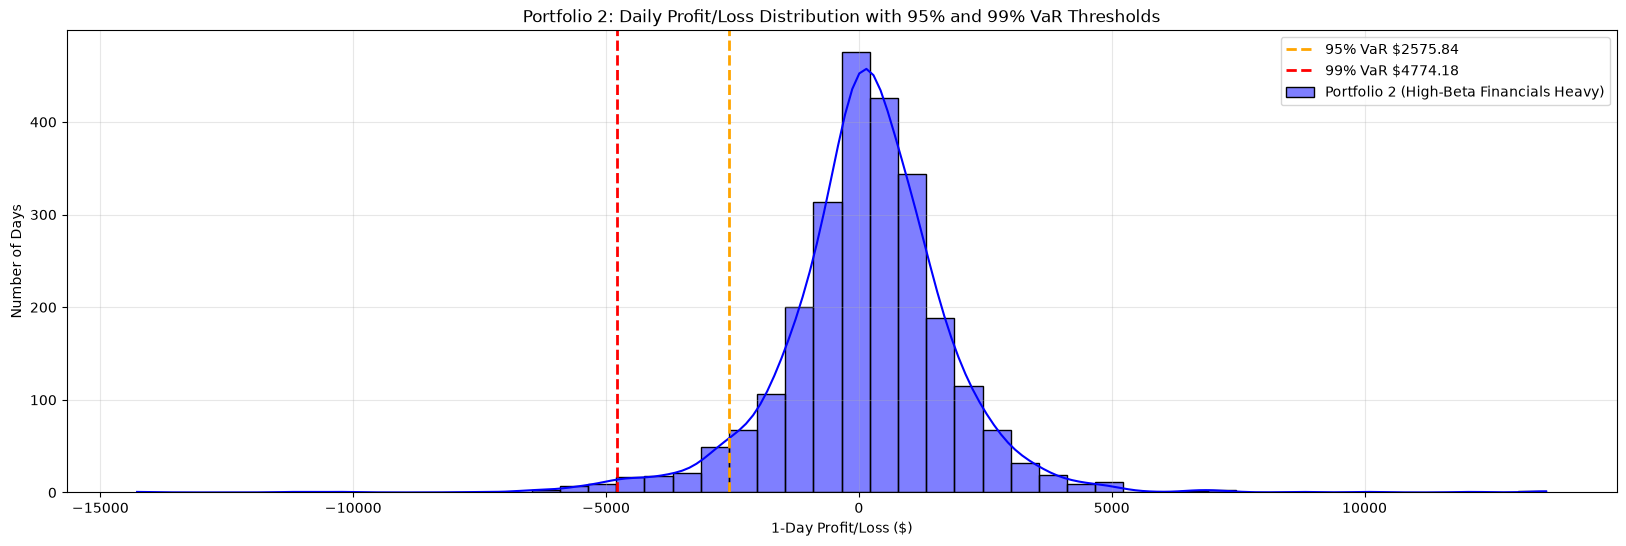

In [12]:
#Since Portfolio 2 is the most concentrated and has the highest beta, we will plot the distribution of its daily returns and overlay the 95% and 99% VaR thresholds on the histogram
plt.figure(figsize=(20, 6))
sns.histplot(portfolio2_returns, bins=50, kde=True, color='blue', alpha=0.5, label='Portfolio 2 (High-Beta Financials Heavy)')

plt.axvline(-histvar95_pf2, color='orange', linestyle='--', linewidth=2, label=f'95% VaR ${histvar95_pf2:.2f}')
plt.axvline(-histvar99_pf2, color='red', linestyle='--', linewidth=2, label=f'99% VaR ${histvar99_pf2:.2f}')

plt.xlabel('1-Day Profit/Loss ($)')
plt.ylabel('Number of Days')
plt.title('Portfolio 2: Daily Profit/Loss Distribution with 95% and 99% VaR Thresholds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


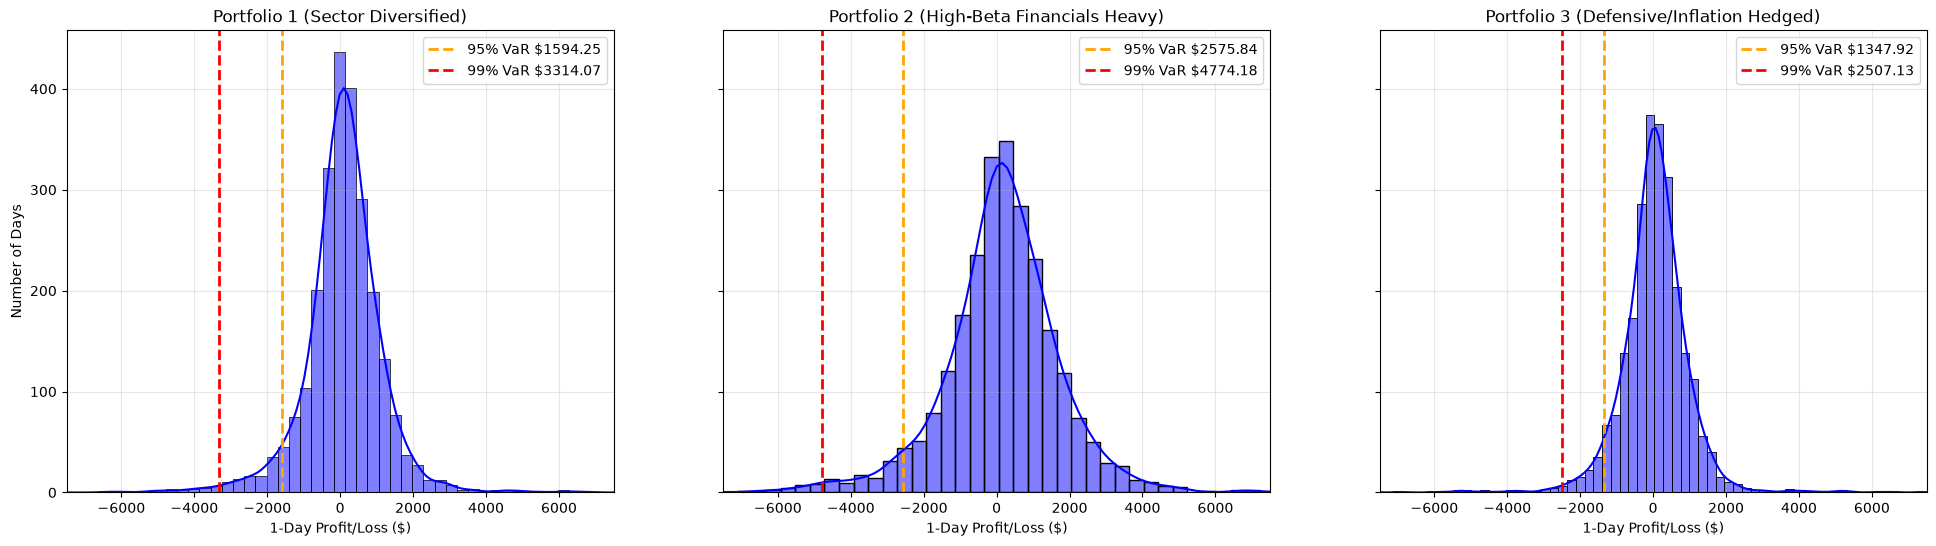

In [13]:
#We can now expand this to all 3 portfolios, so we can visually compare
portfolios = [
    ("Portfolio 1 (Sector Diversified)", portfolio1_returns),
    ("Portfolio 2 (High-Beta Financials Heavy)", portfolio2_returns),
    ("Portfolio 3 (Defensive/Inflation Hedged)", portfolio3_returns)
]

#Create the side by side plots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 6), sharex=True, sharey=True)

for i, (title, returns) in enumerate(portfolios):
    histvar95 = returns.quantile(0.05)
    histvar99 = returns.quantile(0.01)
    
    sns.histplot(returns, bins=70, kde=True, color='blue', alpha=0.5, ax=axes[i])
    axes[i].axvline(histvar95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR ${-histvar95:.2f}')
    axes[i].axvline(histvar99, color='red', linestyle='--', linewidth=2, label=f'99% VaR ${-histvar99:.2f}')

    axes[i].set_xlim(-7500, 7500)  # Set x-axis limits for better comparison (this does mean losing some of the extreme tails, but it will make the plots more comparable)
    axes[i].set_title(title)
    axes[i].set_xlabel('1-Day Profit/Loss ($)')
    axes[i].set_ylabel('Number of Days')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

What's interesting about this is that the VaR for Portfolio 3 has actually come out the lowest of all the portfolios, not somewhere between the Diversified and High-Beta porfolios as hypothesised. This suggests that the low volatility of the healthcare and consumer staples sectors outweighed the added volatility from the energy sectors (at least under historical simulation). It will be worth checking whether this holds under the parametric and Monte Carlo approaches too, since historical simulation is sensitive to the market conditions of the sample period used (here 2016-2026).

## 6. Parametric (Variance-Covariance) VaR

Parametric (Variance Covariance) VaR is an analytical approach that calculates the risk by fitting portfolio returns to a theoretical normal distribution rather than sorting raw empirical data. Conceptually, rather than replaying historic scenarios day by day, the model sumarises the historical price history into the two main statistrical parameters:

- $\mu_p$: the portfolio's expected mean return

- $\sigma_p$: the standard deviation/volatility (derived from the asset covariance matrix $\Sigma$)

These are then used to scale a standard normal distribution to then calculate the VaR at each confidence level.



In [14]:
#First we will calculate the covariance matrix of the daily returns for all assets in the portfolios. This will be used to calculate the portfolio volatility and standard deviation.
cov_matrix = pct_return.cov()

# Display the covariance matrix with a gradient background for better visualization
display(cov_matrix.style.format("{:,.6f}").background_gradient(cmap="coolwarm", axis=None))

Ticker,AAPL,BX,CAT,CVX,JNJ,JPM,KO,MSFT,NVDA,PFE,PG,XOM
Ticker,,,,,,,,,,,,
AAPL,0.000335,0.000208,0.000135,0.000114,0.000065,0.000133,0.000070,0.000209,0.000309,0.000078,0.000075,0.000096
BX,0.000208,0.000508,0.000219,0.000173,0.000065,0.000217,0.000090,0.000209,0.000329,0.000091,0.000077,0.000144
CAT,0.000135,0.000219,0.000366,0.000193,0.000063,0.000201,0.000066,0.000127,0.000215,0.000083,0.000050,0.000181
CVX,0.000114,0.000173,0.000193,0.000341,0.000071,0.000187,0.000080,0.000104,0.000143,0.000078,0.000052,0.000270
JNJ,0.000065,0.000065,0.000063,0.000071,0.000134,0.000070,0.000065,0.000062,0.000041,0.000088,0.000071,0.000060
JPM,0.000133,0.000217,0.000201,0.000187,0.000070,0.000302,0.000082,0.000127,0.000183,0.000088,0.000062,0.000163
KO,0.000070,0.000090,0.000066,0.000080,0.000065,0.000082,0.000129,0.000068,0.000052,0.000065,0.000083,0.000073
MSFT,0.000209,0.000209,0.000127,0.000104,0.000062,0.000127,0.000068,0.000284,0.000328,0.000074,0.000072,0.000078
NVDA,0.000309,0.000329,0.000215,0.000143,0.000041,0.000183,0.000052,0.000328,0.000988,0.000067,0.000058,0.000105


There are a few things we can look at to confirm the matrix above behaves as expected:

* **Symmetry:** The matrix is symmetric across the main diagonal since $\text{Cov}(i, j) = \text{Cov}(j, i)$.
* **Individual Volatilities:** The diagonal elements represent asset variances ($\text{Cov}(i, i) = \text{Var}(i)$). Taking the square root gives daily volatility ($\sigma = \sqrt{\text{Var}(i)}$). We find $\sigma_{\text{NVDA}} \approx 0.0314$ vs $\sigma_{\text{PG}} \approx 0.0118$, confirming that NVIDIA exhibits a higher volatility than consumer staples like Procter & Gamble.
* **Sector Co-movement:** Companies within the same sector exhibit noticeably higher covariances than across sectors. For example, tech companies like Apple and NVIDIA share a covariance of $0.000309$, whereas Apple and Procter & Gamble share a covariance of only $0.000075$.

Next, in order to calculate the variance for each portfolio we will use the formula from Harry Markowitz: $$\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$$

Where $\mathbf{w}$ is the portfolio weight vector that we defined above at the beginning of 5. Historical Simulation VaR, $\mathbf{w}^T$ being the transpose of $\mathbf{w}$ and $\Sigma$ being the covariance matrix.

In [15]:
variance_pf1 = weightspf1.T.dot(cov_matrix).dot(weightspf1)
variance_pf2 = weightspf2.T.dot(cov_matrix).dot(weightspf2)
variance_pf3 = weightspf3.T.dot(cov_matrix).dot(weightspf3)

#We can then from here calculate the standard deviation of each portfolio by taking the square root of the variance. This will give us a measure of the volatility of each portfolio's returns.
std_dev_pf1 = np.sqrt(variance_pf1)
std_dev_pf2 = np.sqrt(variance_pf2)
std_dev_pf3 = np.sqrt(variance_pf3)

#Then displaying this all in a table
display(pd.DataFrame(
    {
        "Portfolio": 
        ["Portfolio 1 (Sector Diversified)", 
         "Portfolio 2 (High-Beta Financials Heavy)", 
         "Portfolio 3 (Defensive/Inflation Hedged)"],

         "Variance":
         [variance_pf1, variance_pf2, variance_pf3],

        "Standard Deviation":
         [std_dev_pf1, std_dev_pf2, std_dev_pf3]
    }
).set_index("Portfolio").style.format("{:,.6f}"))

,Variance,Standard Deviation
Portfolio,,
Portfolio 1 (Sector Diversified),0.000136,0.011646
Portfolio 2 (High-Beta Financials Heavy),0.000293,0.017126
Portfolio 3 (Defensive/Inflation Hedged),0.000095,0.009743


From here we can simply calculate the expected return $\mu_p$ for each portfolio. Using a standard normal $Z$-table, we can see that $z_{\text{0.95}} \approx -1.645$ and $z_{\text{0.99}} \approx -2.326$. Scaling the portfolio standard deviation by the respective $Z$-score, adjusting for the mean drift ($\mu_p$), and multiplying by the $\$100,000$ base portfolio value yields the VaR under a fitted normal distribution.

In [16]:
#Calculating the expected return for all assets in the portfolios
mean_returns = pct_return.mean()

#Now the weighted expected return for each portfolio can be calculated by taking the dot product of the mean returns and the weight vector for each portfolio
mu_pf1 = mean_returns.dot(weightspf1)
mu_pf2 = mean_returns.dot(weightspf2)
mu_pf3 = mean_returns.dot(weightspf3)

In [17]:
#We will import the norm function from scipy.stats to calculate an accurate z-score for the 95% and 99% confidence levels, which will be more accurate for the following calculations.
from scipy.stats import norm

z_95 = norm.ppf(0.05)
z_99 = norm.ppf(0.01)

#We can now calculate the parametric VaR for each portfolio, at each confidence level
paravar95_pf1 = abs(mu_pf1 + z_95 * std_dev_pf1) * 100000
paravar95_pf2 = abs(mu_pf2 + z_95 * std_dev_pf2) * 100000
paravar99_pf1 = abs(mu_pf1 + z_99 * std_dev_pf1) * 100000

paravar99_pf2 = abs(mu_pf2 + z_99 * std_dev_pf2) * 100000
paravar95_pf3 = abs(mu_pf3 + z_95 * std_dev_pf3) * 100000
paravar99_pf3 = abs(mu_pf3 + z_99 * std_dev_pf3) * 100000

In [18]:
#We can now compare the historical and parametric VaR for each portfolio in a table
display(pd.DataFrame(
    {
        "Portfolio": 
        ["Portfolio 1 (Sector Diversified)", 
         "Portfolio 2 (High-Beta Financials Heavy)", 
         "Portfolio 3 (Defensive/Inflation Hedged)"],

         "Historical VaR (95%)":
         [histvar95_pf1, histvar95_pf2, histvar95_pf3],

        "Parametric VaR (95%)":
         [paravar95_pf1, paravar95_pf2, paravar95_pf3],

        "Historical VaR (99%)":
         [histvar99_pf1, histvar99_pf2, histvar99_pf3],

        "Parametric VaR (99%)":
         [paravar99_pf1, paravar99_pf2, paravar99_pf3]
    }
).set_index("Portfolio").style.format("${:,.2f}"))

,Historical VaR (95%),Parametric VaR (95%),Historical VaR (99%),Parametric VaR (99%)
Portfolio,,,,
Portfolio 1 (Sector Diversified),"$1,594.25","$1,827.70","$3,314.07","$2,621.34"
Portfolio 2 (High-Beta Financials Heavy),"$2,575.84","$2,670.53","$4,774.18","$3,837.68"
Portfolio 3 (Defensive/Inflation Hedged),"$1,347.92","$1,560.80","$2,507.13","$2,224.80"


We can now visualise where the normal distribution diverges from the historical data by overlaying a normal distribution 

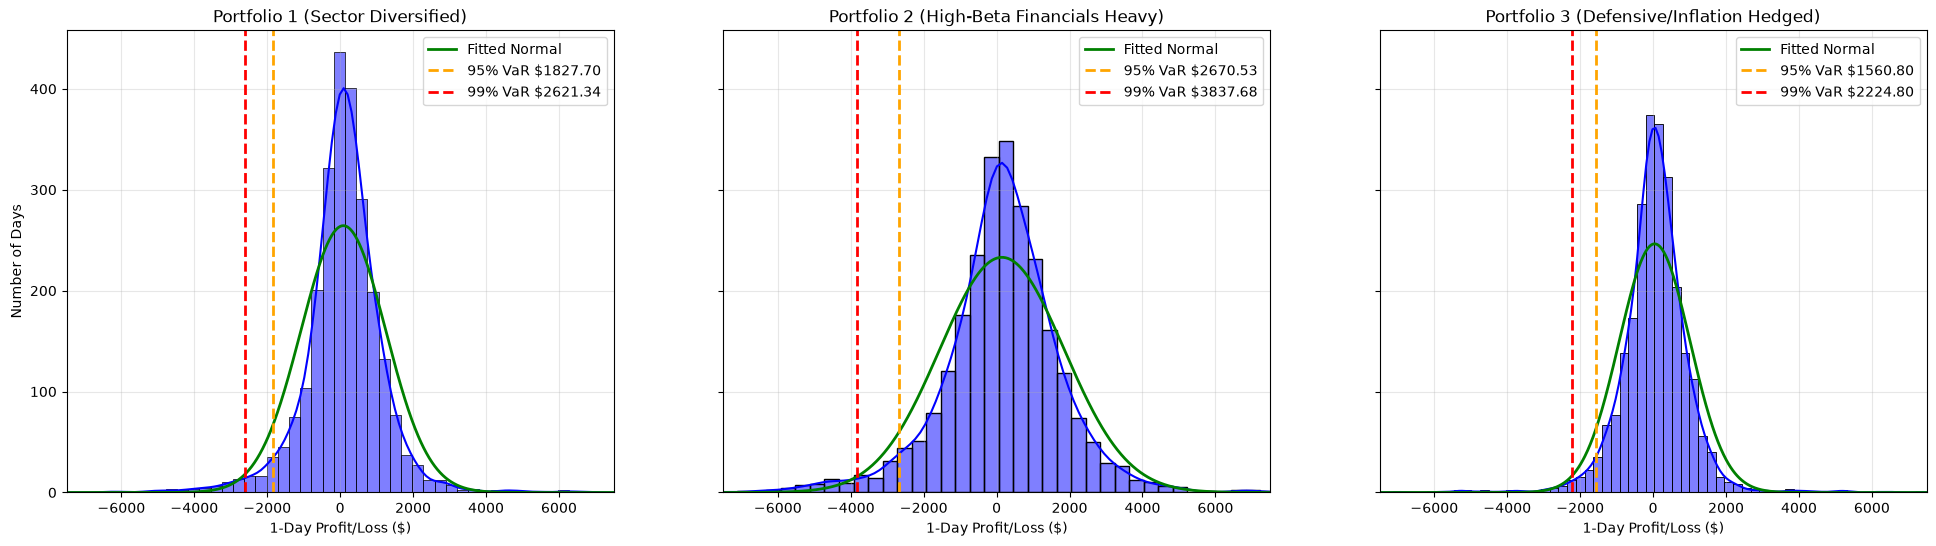

In [25]:
#Using the code from before, adding in the mu and std_dev for each portfolio, and altering it to plot the parametric VaR and overlay a normal distribution curve on top of the histogram of returns for each portfolio
portfolios = [
    ("Portfolio 1 (Sector Diversified)", portfolio1_returns, mu_pf1, std_dev_pf1),
    ("Portfolio 2 (High-Beta Financials Heavy)", portfolio2_returns, mu_pf2, std_dev_pf2),
    ("Portfolio 3 (Defensive/Inflation Hedged)", portfolio3_returns, mu_pf3, std_dev_pf3)
]

#Create the side by side plots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 6), sharex=True, sharey=True)

for i, (title, returns, mu, std_dev) in enumerate(portfolios):
    paravar95 = (mu + z_95 * std_dev) * 100000
    paravar99 = (mu + z_99 * std_dev) * 100000
    
    sns.histplot(returns, bins=70, kde=True, color='blue', alpha=0.5, ax=axes[i])
    #Normal distribution overlay
    x_values = np.linspace(-7500, 7500, 1000)
    axes[i].plot(x_values, norm.pdf(x_values, mu * 100000, std_dev * 100000) * len(returns) * (returns.max() - returns.min())/70, color='green', label='Fitted Normal', linewidth=2)


    axes[i].axvline(paravar95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR ${-paravar95:.2f}')
    axes[i].axvline(paravar99, color='red', linestyle='--', linewidth=2, label=f'99% VaR ${-paravar99:.2f}')

    axes[i].set_xlim(-7500, 7500)  # Set x-axis limits for better comparison (this does mean losing some of the extreme tails, but it will make the plots more comparable)
    axes[i].set_title(title)
    axes[i].set_xlabel('1-Day Profit/Loss ($)')
    axes[i].set_ylabel('Number of Days')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

Comparing historical and parametric VaR reveals a consistent pattern across all three portfolios: parametric VaR is higher than historical at the 95% confidence level, but lower at the 99% level. 